In [99]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# Descriptive + Diagnostic + Predictive Analysis
# With Visualizations
# ============================================================

# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Import Libraries

Import the Python libraries required for:

* Data manipulation
* Numerical analysis
* Data visualization
* Machine learning
* Model evaluation


In [100]:
# ==========================================
# 2. SET PROJECT FOLDER
# ==========================================

project_folder = os.getcwd()

print("Current project folder:")
print(project_folder)

# Dataset file
file_path = os.path.join(project_folder, "creditcard.csv")

print("\nDataset path:")
print(file_path)

Current project folder:
c:\Users\pravi\PycharmProjects

Dataset path:
c:\Users\pravi\PycharmProjects\creditcard.csv


# 2. Set Project Folder

Identify the current Jupyter Notebook working directory.

The project will use this directory to locate `creditcard.csv` and save the final prediction file.

This avoids hard-coding a Windows-specific path.


In [101]:
# ==========================================
# 3. LOAD DATASET
# ==========================================

file_path = r"C:\Users\pravi\PycharmProjects\JupyterProject\Credit_Card_Fraud\creditcard.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"creditcard.csv was not found.\n\n"
        f"Expected location:\n{file_path}"
    )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 284,807
Columns : 31


# 3. Load Dataset

Load `creditcard.csv` into a Pandas DataFrame.

The dataset contains historical credit card transactions and the `Class` column indicates whether a transaction is legitimate or fraudulent.


In [102]:
# ==========================================
# 4. BASIC DATA INFORMATION
# ==========================================

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset shape:
(284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

# 4. Basic Data Information

Examine the structure of the dataset.

We check:

* Number of rows
* Number of columns
* Column names
* Data types
* First few records
* Overall dataset information


In [103]:
# ==========================================
# 5. CHECK MISSING VALUES
# ==========================================

missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found.")

Missing values by column:


Series([], dtype: int64)

No missing values found.


# 5. Check Missing Values

Check every column for missing values.

Missing-value analysis is an important part of data cleaning before performing statistical analysis or machine learning.


In [104]:
# ==========================================
# 6. CHECK DUPLICATE RECORDS
# ==========================================

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 1,081


# 6. Check Duplicate Records

Check whether duplicate transaction records exist in the dataset.

Duplicate records can affect descriptive statistics and machine learning results.


In [105]:
# ==========================================
# 7. REMOVE DUPLICATE RECORDS
# ==========================================

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate records removed.")
else:
    print("No duplicate records to remove.")

print(f"Current dataset shape: {df.shape}")

Duplicate records removed.
Current dataset shape: (283726, 31)


# 7. Remove Duplicate Records

Remove duplicate records if they exist.

The cleaned dataset will be used for the remaining analysis.


In [106]:
# ==========================================
# 8. DESCRIPTIVE STATISTICS
# ==========================================

print("Descriptive statistics:")
display(df.describe().T)

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


# 8. Descriptive Statistics

Generate descriptive statistics for the numerical variables.

This helps understand:

* Mean
* Standard deviation
* Minimum
* Maximum
* Quartiles
* Distribution of transaction values


In [107]:
# ==========================================
# 9. FRAUD DISTRIBUTION
# ==========================================

class_counts = df["Class"].value_counts()

print("Transaction Class Counts:")
print(class_counts)

print("\nTransaction Class Percentages:")
class_percentages = df["Class"].value_counts(normalize=True) * 100
print(class_percentages)

legitimate_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)

print(f"\nLegitimate transactions: {legitimate_count:,}")
print(f"Fraudulent transactions : {fraud_count:,}")
print(f"Fraud percentage        : {(fraud_count / len(df)) * 100:.4f}%")

Transaction Class Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Transaction Class Percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Legitimate transactions: 283,253
Fraudulent transactions : 473
Fraud percentage        : 0.1667%


# 9. Fraud Distribution

Analyze the distribution of legitimate and fraudulent transactions.

The `Class` variable contains:

* `0` = Legitimate transaction
* `1` = Fraudulent transaction

The purpose of this step is to understand the severe class imbalance in the dataset.


In [108]:
# ==========================================
# 10. FRAUD AMOUNT ANALYSIS
# ==========================================

legitimate_amount = df[df["Class"] == 0]["Amount"]
fraud_amount = df[df["Class"] == 1]["Amount"]

print("Legitimate Transaction Amount:")
print(legitimate_amount.describe())

print("\nFraudulent Transaction Amount:")
print(fraud_amount.describe())

print("\nAverage Legitimate Transaction Amount:")
print(f"{legitimate_amount.mean():.2f}")

print("\nAverage Fraudulent Transaction Amount:")
print(f"{fraud_amount.mean():.2f}")

Legitimate Transaction Amount:
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transaction Amount:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Average Legitimate Transaction Amount:
88.41

Average Fraudulent Transaction Amount:
123.87


# 10. Fraud Amount Analysis

Compare transaction amounts between legitimate and fraudulent transactions.

This helps determine whether transaction value differs between the two classes.


In [109]:
# ==========================================
# 11. TRANSACTION TIME ANALYSIS
# ==========================================

print("Average transaction time:")

print(
    f"Legitimate: "
    f"{df[df['Class'] == 0]['Time'].mean():.2f} seconds"
)

print(
    f"Fraudulent: "
    f"{df[df['Class'] == 1]['Time'].mean():.2f} seconds"
)

Average transaction time:
Legitimate: 94835.06 seconds
Fraudulent: 80450.51 seconds


# 11. Transaction Time Analysis

Analyze transaction timing for legitimate and fraudulent transactions.

The `Time` feature represents the number of seconds elapsed between a transaction and the first transaction in the dataset.


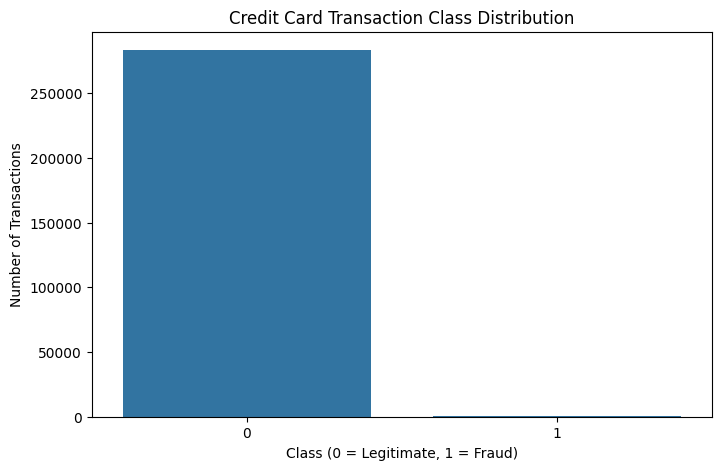

In [110]:
# ==========================================
# 12. CLASS DISTRIBUTION VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

# 12. Class Distribution Visualization

Visualize the number of legitimate and fraudulent transactions.

This graph demonstrates the extreme class imbalance present in the dataset.


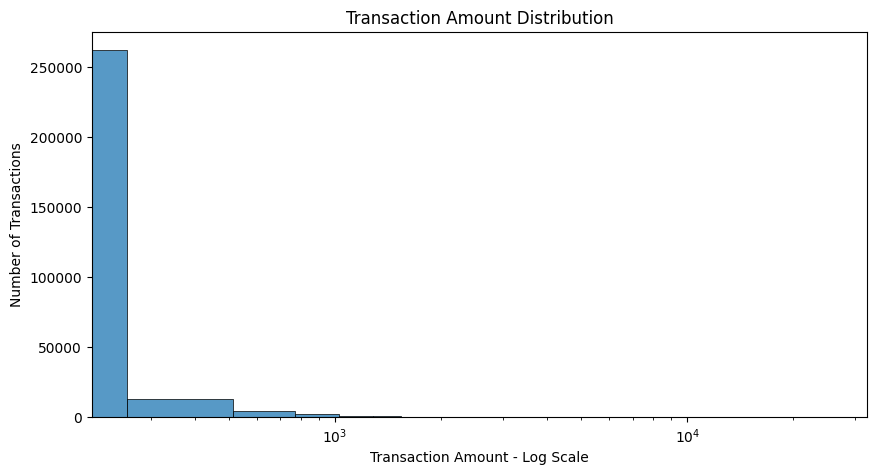

In [111]:
# ==========================================
# 13. TRANSACTION AMOUNT DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.xscale("log")

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount - Log Scale")
plt.ylabel("Number of Transactions")

plt.show()

# 13. Transaction Amount Distribution

Visualize the distribution of transaction amounts.

A logarithmic scale is used because transaction amounts can have a highly skewed distribution.


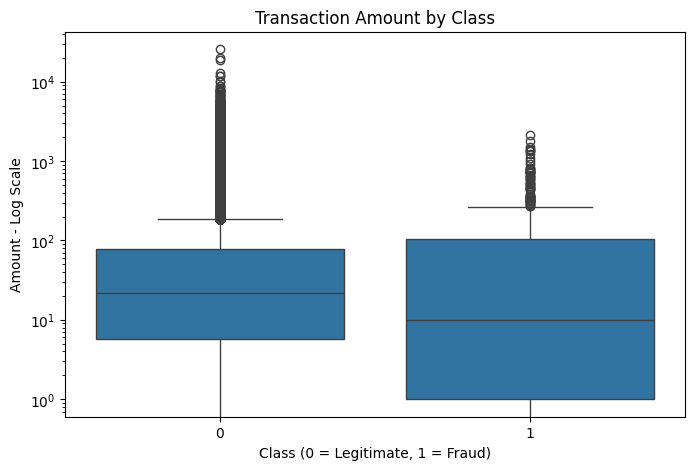

In [112]:
# ==========================================
# 14. FRAUD VS LEGITIMATE AMOUNT
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount - Log Scale")

plt.show()

# 14. Fraud vs Legitimate Transaction Amount

Compare transaction amounts between legitimate and fraudulent transactions using a boxplot.

A logarithmic scale is used to make the distribution easier to visualize.


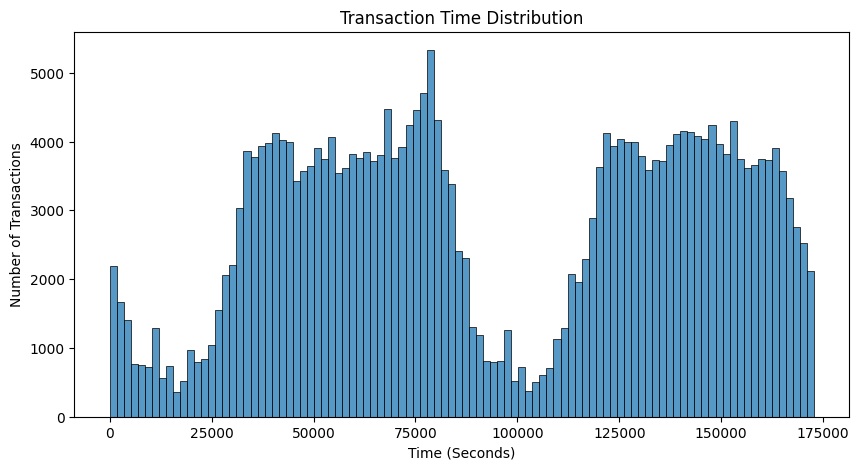

In [113]:
# ==========================================
# 15. TRANSACTION TIME DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (Seconds)")
plt.ylabel("Number of Transactions")

plt.show()

# 15. Transaction Time Distribution

Visualize when transactions occurred during the observation period.

This provides an overview of transaction timing patterns.


In [114]:
# ==========================================
# 16. FRAUD RATE BY TRANSACTION AMOUNT
# ==========================================

df["Amount_Bin"] = pd.qcut(
    df["Amount"],
    q=10,
    duplicates="drop"
)

amount_fraud_rate = (
    df.groupby("Amount_Bin", observed=True)["Class"]
    .mean() * 100
)

print("Fraud rate by transaction amount group:")
display(amount_fraud_rate)

Fraud rate by transaction amount group:


Amount_Bin
(-0.001, 1.0]         0.563780
(1.0, 3.58]           0.097517
(3.58, 8.92]          0.127560
(8.92, 13.04]         0.045975
(13.04, 22.0]         0.049150
(22.0, 37.07]         0.056595
(37.07, 59.9]         0.080642
(59.9, 100.0]         0.171569
(100.0, 203.38]       0.153423
(203.38, 25691.16]    0.289017
Name: Class, dtype: float64

# 16. Fraud Rate by Transaction Amount

Divide transactions into amount groups and calculate the percentage of fraudulent transactions in each group.

This helps investigate whether fraud frequency changes across transaction-value ranges.


In [115]:
# ==========================================
# 17. FRAUD RATE BY TIME GROUP
# ==========================================

df["Time_Bin"] = pd.qcut(
    df["Time"],
    q=10,
    duplicates="drop"
)

time_fraud_rate = (
    df.groupby("Time_Bin", observed=True)["Class"]
    .mean() * 100
)

print("Fraud rate by transaction time group:")
display(time_fraud_rate)

Fraud rate by transaction time group:


Time_Bin
(-0.001, 35028.0]       0.327765
(35028.0, 47702.0]      0.225567
(47702.0, 60770.5]      0.165662
(60770.5, 73272.0]      0.112783
(73272.0, 84692.5]      0.091640
(84692.5, 120393.0]     0.281958
(120393.0, 132906.0]    0.084587
(132906.0, 145234.0]    0.116308
(145234.0, 157631.0]    0.183279
(157631.0, 172792.0]    0.077541
Name: Class, dtype: float64

# 17. Fraud Rate by Transaction Time

Divide transactions into time groups and calculate the fraud rate for each group.

This helps identify whether fraud concentration changes across the transaction timeline.


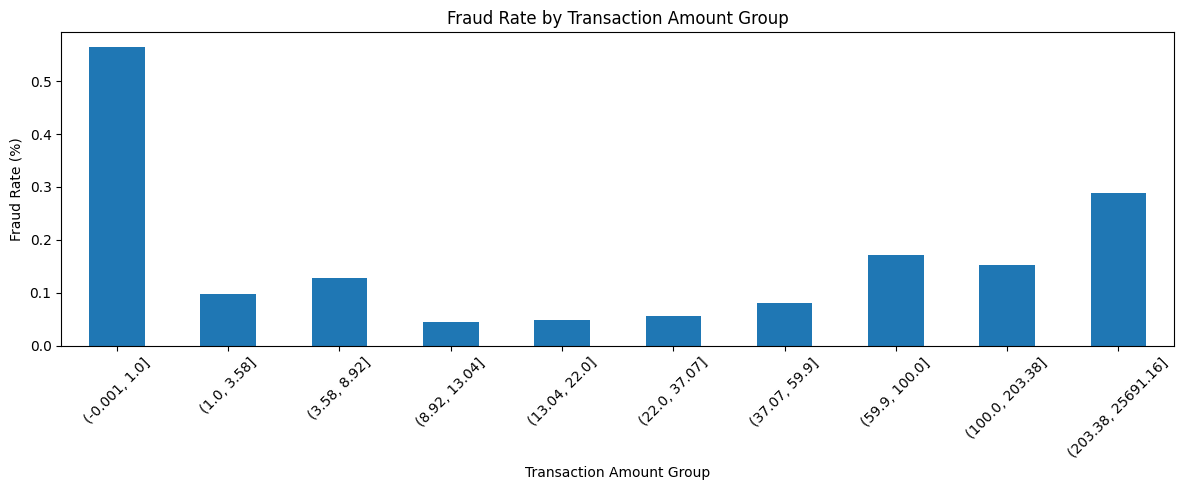

In [116]:
# ==========================================
# 18. FRAUD RATE BY AMOUNT GROUP
# ==========================================

plt.figure(figsize=(12, 5))

amount_fraud_rate.plot(
    kind="bar"
)

plt.title("Fraud Rate by Transaction Amount Group")
plt.xlabel("Transaction Amount Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 18. Fraud Rate by Amount Group

Visualize the fraud rate across transaction amount groups.

This is part of the diagnostic analysis used to investigate potential relationships between transaction amount and fraud.


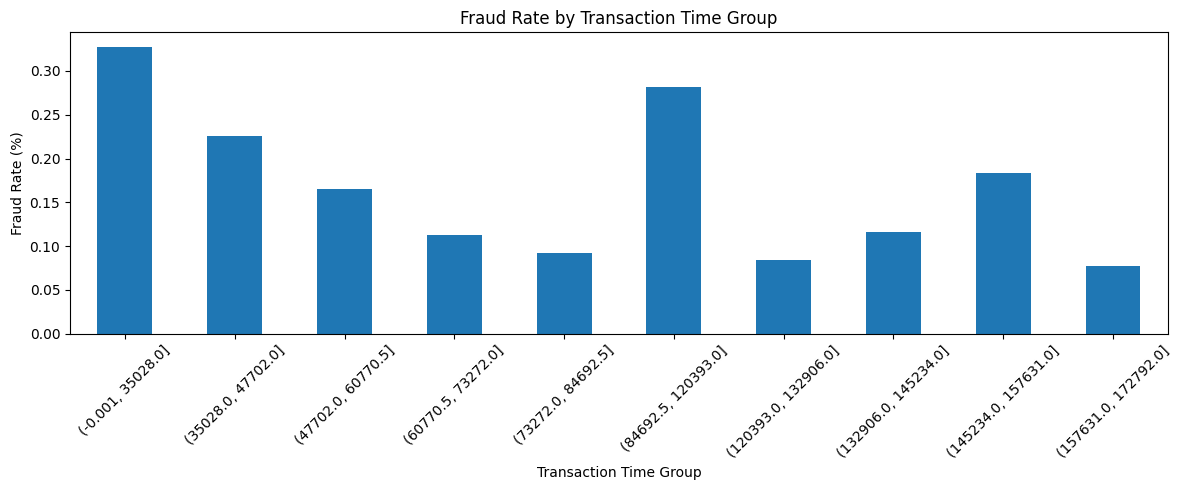

In [117]:
# ==========================================
# 19. FRAUD RATE BY TIME GROUP
# ==========================================

plt.figure(figsize=(12, 5))

time_fraud_rate.plot(
    kind="bar"
)

plt.title("Fraud Rate by Transaction Time Group")
plt.xlabel("Transaction Time Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 19. Fraud Rate by Time Group

Visualize fraud rates across different transaction-time groups.

This helps investigate potential temporal patterns in fraudulent activity.


In [118]:
# ==========================================
# 20. CORRELATION ANALYSIS
# ==========================================

correlation = df.drop(
    columns=["Amount_Bin", "Time_Bin"],
    errors="ignore"
).corr()

class_correlation = (
    correlation["Class"]
    .drop("Class")
    .sort_values(ascending=False)
)

print("Features positively correlated with fraud:")
display(class_correlation.head(10))

print("\nFeatures negatively correlated with fraud:")
display(class_correlation.tail(10))

Features positively correlated with fraud:


V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64


Features negatively correlated with fraud:


V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64

# 20. Correlation Analysis

Calculate correlations between the numerical features and the target variable.

The purpose is to identify features that show stronger positive or negative relationships with the fraud class.

Correlation does not prove causation; it is used here as an exploratory diagnostic tool.


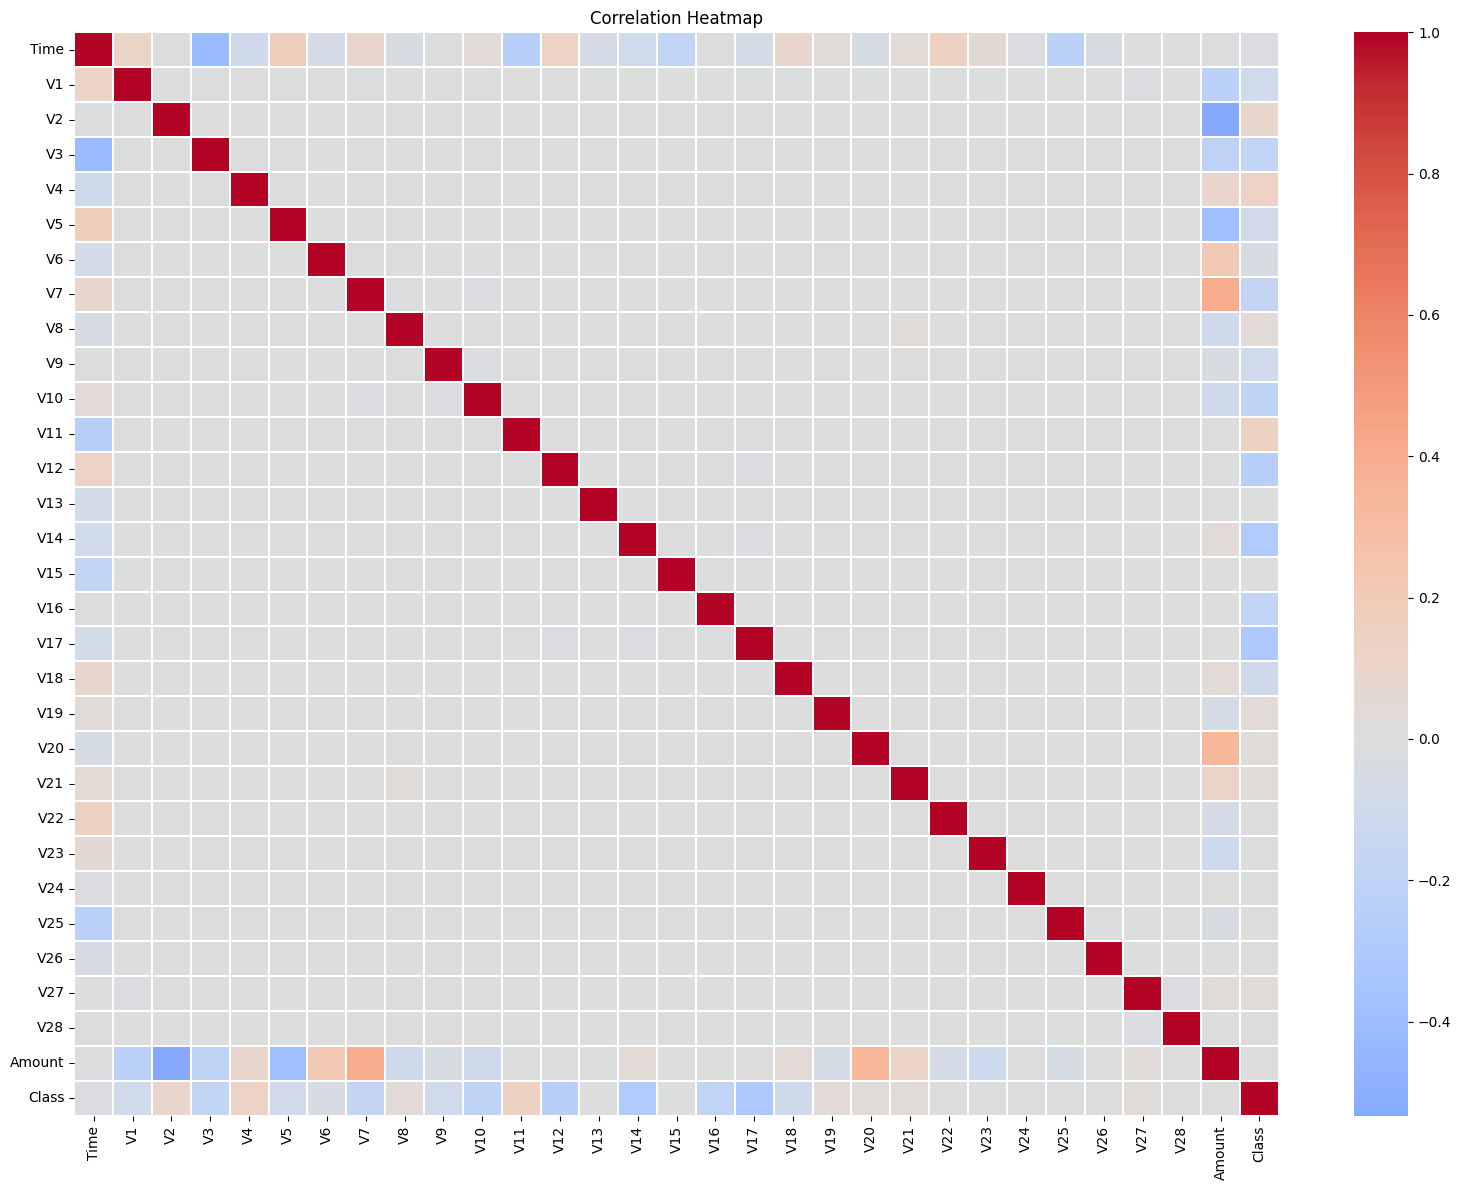

In [119]:
# ==========================================
# 21. CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

# 21. Correlation Heatmap

Visualize correlations between the numerical features using a heatmap.

The visualization helps identify patterns and relationships among the anonymized PCA features, `Time`, `Amount`, and `Class`.


In [120]:
# ==========================================
# 22. REMOVE TEMPORARY ANALYSIS COLUMNS
# ==========================================

df_model = df.drop(
    columns=["Amount_Bin", "Time_Bin"],
    errors="ignore"
).copy()

print("Model dataset shape:")
print(df_model.shape)

Model dataset shape:
(283726, 31)


# 22. Prepare Model Dataset

Remove temporary analysis columns created during diagnostic analysis.

The resulting DataFrame will be used for machine learning.


In [121]:
# ==========================================
# 23. SEPARATE FEATURES AND TARGET
# ==========================================

X = df_model.drop("Class", axis=1)

y = df_model["Class"]

print("Features shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape:
(283726, 30)

Target shape:
(283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


# 23. Separate Features and Target

Separate the dataset into:

* `X` — predictor features
* `y` — target variable

The target variable is `Class`.

`Class = 0` represents legitimate transactions and `Class = 1` represents fraudulent transactions.


In [122]:
# ==========================================
# 24. TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print(X_train.shape)

print("\nTesting data:")
print(X_test.shape)

print("\nFraud cases in training data:")
print(y_train.sum())

print("\nFraud cases in testing data:")
print(y_test.sum())

Training data:
(226980, 30)

Testing data:
(56746, 30)

Fraud cases in training data:
378

Fraud cases in testing data:
95


# 24. Train-Test Split

Split the dataset into training and testing datasets.

An 80/20 split is used.

The `stratify` parameter is used to preserve the proportion of fraudulent and legitimate transactions in both datasets.

This is particularly important because the dataset contains an extremely small number of fraud cases.


In [123]:
# ==========================================
# 25. FEATURE SCALING
# ==========================================

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Feature scaling completed.")

Feature scaling completed.


# 25. Feature Scaling

Scale the `Time` and `Amount` features using `StandardScaler`.

The PCA-derived `V1`–`V28` features are already transformed.

Scaling helps Logistic Regression operate effectively when features have different numerical ranges.


In [124]:
# ==========================================
# 26. CREATE LOGISTIC REGRESSION MODEL
# ==========================================

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


# 26. Create Logistic Regression Model

Create a Logistic Regression classification model.

The model uses:

```python
class_weight="balanced"
```

because fraudulent transactions represent only a very small percentage of the dataset.

This gives greater importance to the minority fraud class during model training.


In [125]:
# ==========================================
# 27. TRAIN THE MODEL
# ==========================================

print("Training model...")

model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed.")

Training model...
Model training completed.


# 27. Train the Machine Learning Model

Train the Logistic Regression model using the scaled training data.

The model learns patterns that distinguish fraudulent transactions from legitimate transactions.


In [126]:
# ==========================================
# 28. MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test_scaled)

y_pred_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


# 28. Make Predictions

Generate:

1. Predicted transaction class
2. Probability that each transaction is fraudulent

Fraud probability will later be used to create risk categories.


In [127]:
# ==========================================
# 29. MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_probability
)

pr_auc = average_precision_score(
    y_test,
    y_pred_probability
)

print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"PR-AUC         : {pr_auc:.4f}")

MODEL PERFORMANCE
Accuracy       : 0.9752
Precision      : 0.0562
Recall         : 0.8737
F1 Score       : 0.1057
ROC-AUC        : 0.9658
PR-AUC         : 0.6719


# 29. Model Evaluation

Evaluate the model using:

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC
* PR-AUC

Because this dataset is extremely imbalanced, **Recall, Precision and PR-AUC are especially important**.

Accuracy should not be treated as the primary measure of fraud-detection performance.


In [128]:
# ==========================================
# 30. CLASSIFICATION REPORT
# ==========================================

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



# 30. Classification Report

Generate a classification report containing precision, recall, F1 score and support for both legitimate and fraudulent transactions.

The fraud-class metrics are especially important for evaluating whether the model can identify rare fraudulent transactions.


Confusion Matrix:
[[55258  1393]
 [   12    83]]


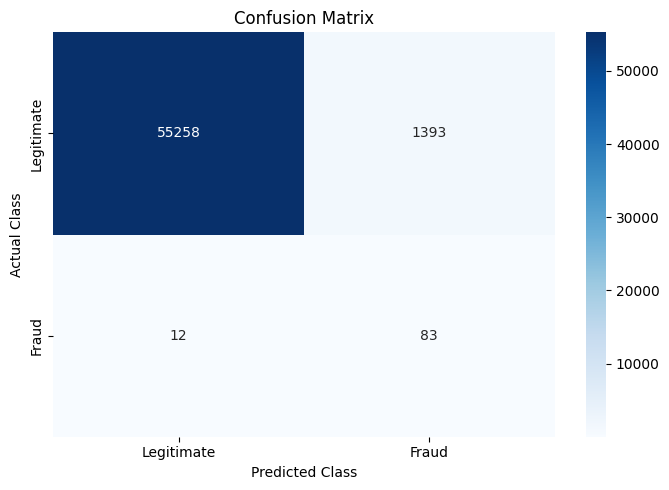

In [129]:
# ==========================================
# 31. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# 31. Confusion Matrix

Create a confusion matrix to examine the number of:

* True Negatives
* False Positives
* False Negatives
* True Positives

For this business problem, False Negatives are especially important because they represent fraudulent transactions that were missed by the model.


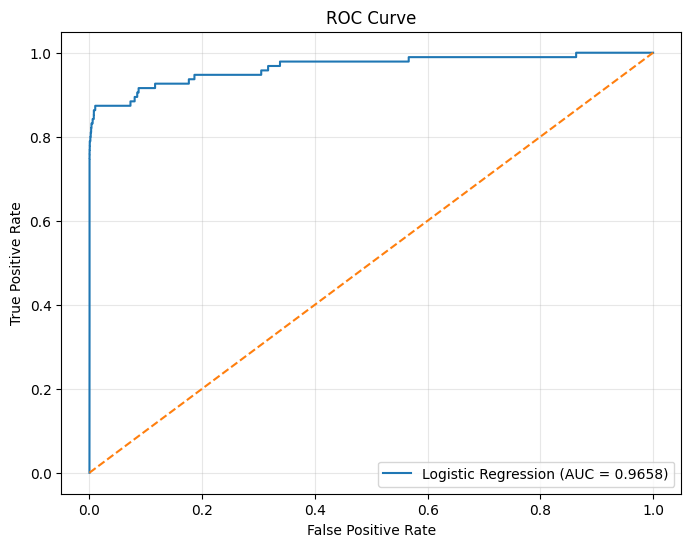

In [130]:
# ==========================================
# 32. ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 32. ROC Curve

Plot the Receiver Operating Characteristic curve and calculate ROC-AUC.

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate across different classification thresholds.


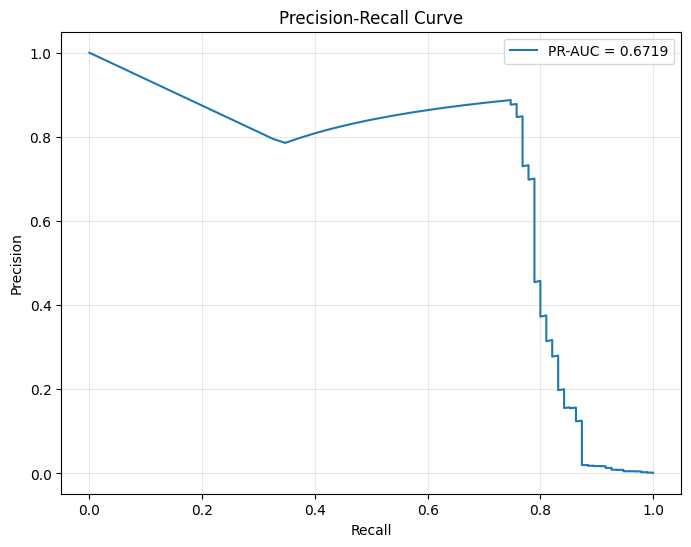

In [131]:
# ==========================================
# 33. PRECISION-RECALL CURVE
# ==========================================

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 33. Precision-Recall Curve

Plot the Precision-Recall curve and calculate PR-AUC.

This metric is particularly useful for this project because fraudulent transactions represent only approximately 0.172% of all transactions.

PR-AUC provides a more informative view of minority-class performance than accuracy alone.


In [132]:
# ==========================================
# 34. FRAUD PROBABILITY
# ==========================================

results = X_test.copy()

results["Actual_Class"] = y_test.values
results["Predicted_Class"] = y_pred
results["Fraud_Probability"] = y_pred_probability

results = results.sort_values(
    by="Fraud_Probability",
    ascending=False
)

print("Top transactions with highest fraud probability:")

display(
    results[
        [
            "Time",
            "Amount",
            "Actual_Class",
            "Predicted_Class",
            "Fraud_Probability"
        ]
    ].head(20)
)

Top transactions with highest fraud probability:


,Time,Amount,Actual_Class,Predicted_Class,Fraud_Probability
41828,40919.0,112.33,1,1,1.0
6695,8451.0,1.00,1,1,1.0
120368,75978.0,99.90,1,1,1.0
156390,109297.0,0.00,1,1,1.0
8806,12095.0,30.39,1,1,1.0
222791,143456.0,1.00,1,1,1.0
43498,41607.0,53.95,1,1,1.0
229227,146179.0,0.77,1,1,1.0
222745,143434.0,1.00,1,1,1.0
150337,94141.0,45.48,1,1,1.0


# 34. Fraud Probability

Calculate the predicted probability of fraud for each test transaction.

Transactions with higher fraud probabilities can be prioritized for additional investigation.


In [133]:
# ==========================================
# 35. CREATE FRAUD RISK CATEGORIES
# ==========================================

def fraud_risk(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


results["Fraud_Risk"] = results[
    "Fraud_Probability"
].apply(fraud_risk)

print("Fraud risk categories created.")

display(
    results[
        [
            "Time",
            "Amount",
            "Actual_Class",
            "Predicted_Class",
            "Fraud_Probability",
            "Fraud_Risk"
        ]
    ].head(20)
)

Fraud risk categories created.


,Time,Amount,Actual_Class,Predicted_Class,Fraud_Probability,Fraud_Risk
41828,40919.0,112.33,1,1,1.0,High Risk
6695,8451.0,1.00,1,1,1.0,High Risk
120368,75978.0,99.90,1,1,1.0,High Risk
156390,109297.0,0.00,1,1,1.0,High Risk
8806,12095.0,30.39,1,1,1.0,High Risk
222791,143456.0,1.00,1,1,1.0,High Risk
43498,41607.0,53.95,1,1,1.0,High Risk
229227,146179.0,0.77,1,1,1.0,High Risk
222745,143434.0,1.00,1,1,1.0,High Risk
150337,94141.0,45.48,1,1,1.0,High Risk


# 35. Create Fraud Risk Categories

Convert fraud probabilities into three business-oriented risk categories:

| Probability | Risk        |
| ----------- | ----------- |
| < 40%       | Low Risk    |
| 40%–69.99%  | Medium Risk |
| ≥ 70%       | High Risk   |

These thresholds are used for demonstration and can be adjusted according to business requirements and the cost of false positives versus missed fraud.


In [134]:
# ==========================================
# 36. FRAUD RISK SUMMARY
# ==========================================

risk_summary = (
    results["Fraud_Risk"]
    .value_counts()
    .reindex(
        ["High Risk", "Medium Risk", "Low Risk"],
        fill_value=0
    )
)

print("Fraud Risk Summary:")
print(risk_summary)

Fraud Risk Summary:
Fraud_Risk
High Risk        712
Medium Risk     1365
Low Risk       54669
Name: count, dtype: int64


# 36. Fraud Risk Summary

Count the number of transactions classified as:

* Low Risk
* Medium Risk
* High Risk

This provides a simple overview of the transactions requiring different levels of attention.


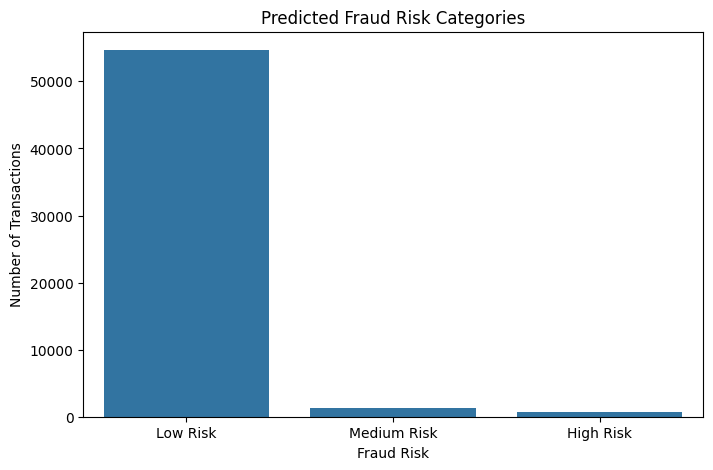

In [135]:
# ==========================================
# 37. FRAUD RISK VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=results,
    x="Fraud_Risk",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Predicted Fraud Risk Categories")
plt.xlabel("Fraud Risk")
plt.ylabel("Number of Transactions")

plt.show()

# 37. Fraud Risk Visualization

Visualize the number of transactions in each fraud-risk category.

This can help a fraud-monitoring team understand how many transactions may require additional review.


In [136]:
# ==========================================
# 38. IDENTIFY HIGH-RISK TRANSACTIONS
# ==========================================

high_risk_transactions = results[
    results["Fraud_Risk"] == "High Risk"
].copy()

print(
    f"Number of high-risk transactions: "
    f"{len(high_risk_transactions):,}"
)

display(
    high_risk_transactions[
        [
            "Time",
            "Amount",
            "Actual_Class",
            "Predicted_Class",
            "Fraud_Probability",
            "Fraud_Risk"
        ]
    ].head(20)
)

Number of high-risk transactions: 712


,Time,Amount,Actual_Class,Predicted_Class,Fraud_Probability,Fraud_Risk
41828,40919.0,112.33,1,1,1.0,High Risk
6695,8451.0,1.00,1,1,1.0,High Risk
120368,75978.0,99.90,1,1,1.0,High Risk
156390,109297.0,0.00,1,1,1.0,High Risk
8806,12095.0,30.39,1,1,1.0,High Risk
222791,143456.0,1.00,1,1,1.0,High Risk
43498,41607.0,53.95,1,1,1.0,High Risk
229227,146179.0,0.77,1,1,1.0,High Risk
222745,143434.0,1.00,1,1,1.0,High Risk
150337,94141.0,45.48,1,1,1.0,High Risk


# 38. Identify High-Risk Transactions

Extract transactions classified as High Risk.

The highest-risk transactions can be prioritized for manual review, additional authentication, or other fraud-control processes.


In [137]:
# ==========================================
# 39. ACTUAL FRAUD CASES DETECTED
# ==========================================

actual_fraud = results[
    results["Actual_Class"] == 1
]

detected_fraud = actual_fraud[
    actual_fraud["Predicted_Class"] == 1
]

missed_fraud = actual_fraud[
    actual_fraud["Predicted_Class"] == 0
]

print(f"Actual fraud cases       : {len(actual_fraud):,}")
print(f"Detected fraud cases     : {len(detected_fraud):,}")
print(f"Missed fraud cases       : {len(missed_fraud):,}")

print(
    f"\nFraud detection recall: "
    f"{len(detected_fraud) / len(actual_fraud) * 100:.2f}%"
)

Actual fraud cases       : 95
Detected fraud cases     : 83
Missed fraud cases       : 12

Fraud detection recall: 87.37%


# 39. Actual Fraud Detection Performance

Compare the model's predictions against the actual fraud cases.

Calculate:

* Total actual fraud cases
* Fraud cases correctly detected
* Fraud cases missed
* Fraud detection recall

This directly connects model performance to the business problem.


In [138]:
# ==========================================
# 40. EXPORT FRAUD PREDICTIONS
# ==========================================

output_file = os.path.join(
    project_folder,
    "credit_card_fraud_predictions.csv"
)

results.to_csv(
    output_file,
    index=False
)

print("Prediction file created successfully!")
print("\nSaved at:")
print(output_file)

Prediction file created successfully!

Saved at:
c:\Users\pravi\PycharmProjects\credit_card_fraud_predictions.csv


# 40. Export Fraud Predictions

Export the prediction results to:

`credit_card_fraud_predictions.csv`

The output file is automatically saved in the same folder as the Jupyter Notebook.

The output contains transaction information, actual class, predicted class, fraud probability and fraud-risk category.


In [139]:
# ==========================================
# 41. BUSINESS INSIGHTS
# ==========================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\n1. Total transactions analyzed: "
    f"{len(df):,}"
)

print(
    f"2. Actual fraudulent transactions: "
    f"{int(df['Class'].sum()):,}"
)

print(
    f"3. Fraud rate: "
    f"{df['Class'].mean() * 100:.4f}%"
)

print(
    f"4. Fraud detection recall: "
    f"{recall * 100:.2f}%"
)

print(
    f"5. Fraud detection precision: "
    f"{precision * 100:.2f}%"
)

print(
    f"6. PR-AUC: "
    f"{pr_auc:.4f}"
)

print(
    f"7. High-risk transactions identified: "
    f"{len(high_risk_transactions):,}"
)

print("\nBusiness Interpretation:")
print(
    "- High recall helps reduce missed fraudulent transactions."
)

print(
    "- High precision helps reduce false alarms for genuine customers."
)

print(
    "- PR-AUC is especially useful because fraud represents "
    "a very small percentage of all transactions."
)

print(
    "- High-risk transactions can be prioritized for additional "
    "verification or review."
)

BUSINESS INSIGHTS

1. Total transactions analyzed: 283,726
2. Actual fraudulent transactions: 473
3. Fraud rate: 0.1667%
4. Fraud detection recall: 87.37%
5. Fraud detection precision: 5.62%
6. PR-AUC: 0.6719
7. High-risk transactions identified: 712

Business Interpretation:
- High recall helps reduce missed fraudulent transactions.
- High precision helps reduce false alarms for genuine customers.
- PR-AUC is especially useful because fraud represents a very small percentage of all transactions.
- High-risk transactions can be prioritized for additional verification or review.


# 41. Business Insights

Summarize the key findings from the analysis.

The main business considerations are:

* Reduce missed fraudulent transactions.
* Maintain strong fraud recall.
* Control false positives.
* Prioritize high-risk transactions.
* Use PR-AUC as an important evaluation metric because of extreme class imbalance.
* Use predicted fraud probabilities to support transaction-review decisions.
